## Preparing the dataset

- Preparation:

    - Fill missing values with zeros.
    - Do train/validation/test split with 60%/20%/20% distribution.
    - Use the train_test_split function and set the random_state parameter to 1.
    - Use DictVectorizer(sparse=True) to turn the dataframes into matrices.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text

In [2]:
from matplotlib import pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv("car_fuel_efficiency.csv")
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


In [5]:
df.isna().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [6]:
df = df.fillna(0)

In [7]:
df.isna().sum()

engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

In [8]:
df.origin.value_counts()

Europe    3254
Asia      3247
USA       3203
Name: origin, dtype: int64

In [9]:
origin_values = {
    'Europe' : 0,
    'Asia' : 1,
    'USA' : 2
}

df.origin = df.origin.map(origin_values)
df.origin.value_counts()

0    3254
1    3247
2    3203
Name: origin, dtype: int64

In [10]:
df.fuel_type.value_counts()

Gasoline    4898
Diesel      4806
Name: fuel_type, dtype: int64

In [11]:
fuel_type_values = {
    'Gasoline' : 0,
    'Diesel' : 1
}

df.fuel_type = df.fuel_type.map(fuel_type_values)
df.fuel_type.value_counts()

0    4898
1    4806
Name: fuel_type, dtype: int64

In [12]:
df.drivetrain.value_counts()

All-wheel drive      4876
Front-wheel drive    4828
Name: drivetrain, dtype: int64

In [13]:
drivetrain_values = {
    'All-wheel drive' : 0,
    'Front-wheel drive' : 1
}

df.drivetrain = df.drivetrain.map(drivetrain_values)
df.drivetrain.value_counts()

0    4876
1    4828
Name: drivetrain, dtype: int64

In [14]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [15]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [16]:
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

In [17]:
del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

In [18]:
train_dicts = df_train.to_dict(orient='records')
dv = DictVectorizer(sparse=True)

In [19]:
sparse_matrix = dv.fit_transform(train_dicts)
feature_names = dv.get_feature_names_out()
print(feature_names)

['acceleration' 'drivetrain' 'engine_displacement' 'fuel_type'
 'horsepower' 'model_year' 'num_cylinders' 'num_doors' 'origin'
 'vehicle_weight']


In [20]:
X_train = sparse_matrix.toarray()
X_train

array([[ 1.39000000e+01,  1.00000000e+00,  1.20000000e+02, ...,
        -1.00000000e+00,  2.00000000e+00,  2.96667950e+03],
       [ 1.71000000e+01,  1.00000000e+00,  2.00000000e+02, ...,
        -1.00000000e+00,  1.00000000e+00,  2.95082212e+03],
       [ 1.74000000e+01,  0.00000000e+00,  1.80000000e+02, ...,
         0.00000000e+00,  2.00000000e+00,  3.07822167e+03],
       ...,
       [ 1.67000000e+01,  0.00000000e+00,  2.30000000e+02, ...,
         0.00000000e+00,  0.00000000e+00,  3.04196459e+03],
       [ 1.52000000e+01,  0.00000000e+00,  1.80000000e+02, ...,
         0.00000000e+00,  0.00000000e+00,  2.45334143e+03],
       [ 1.41000000e+01,  1.00000000e+00,  1.90000000e+02, ...,
         0.00000000e+00,  2.00000000e+00,  2.83389943e+03]])

## Question 1
Let's train a decision tree regressor to predict the fuel_efficiency_mpg variable.

Train a model with max_depth=1.
Which feature is used for splitting the data?

   - 'vehicle_weight'
   - 'model_year'
   - 'origin'
   - 'fuel_type'

In [21]:
dt1 = DecisionTreeRegressor(max_depth=1)
dt1.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [22]:
# val_dicts = df_val.to_dict(orient='records')
# X_val = dv.transform(val_dicts)
# X_val = X_val.toarray()
# # X_val
# y_pred = dt1.predict(X_val)
# y_pred

In [23]:
print(export_text(dt1, feature_names=dv.get_feature_names_out()))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



In [24]:
# 'vehicle_weight'

## Question 2
Train a random forest regressor with these parameters:

- n_estimators=10
- random_state=1
- n_jobs=-1 (optional - to make training faster)

What's the RMSE of this model on the validation data?

- 0.045
- 0.45
- 4.5
- 45.0

In [25]:
from sklearn.ensemble import RandomForestRegressor

In [26]:
rf1 = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf1.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)
X_val = X_val.toarray()
y_pred = rf1.predict(X_val)

In [28]:
# len(y_pred), len(X_val)

In [29]:
from sklearn.metrics import root_mean_squared_error

In [30]:
root_mean_squared_error(y_val, y_pred)

0.4594485208997226

In [31]:
# 0.45

## Question 3
Now let's experiment with the n_estimators parameter

- Try different values of this parameter from 10 to 200 with step 10.
- Set random_state to 1.
- Evaluate the model on the validation dataset.

After which value of n_estimators does RMSE stop improving? Consider 3 decimal places for calculating the answer.

- 10
- 25
- 80
- 200

If it doesn't stop improving, use the latest iteration number in your answer.

In [32]:
scores = []
for i in range(10, 201, 10):
    rf = RandomForestRegressor(n_estimators=i, random_state=1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    scores.append([i, round(root_mean_squared_error(y_val, y_pred),3)])
scores

[[10, 0.459],
 [20, 0.453],
 [30, 0.451],
 [40, 0.449],
 [50, 0.447],
 [60, 0.446],
 [70, 0.445],
 [80, 0.445],
 [90, 0.445],
 [100, 0.445],
 [110, 0.444],
 [120, 0.444],
 [130, 0.444],
 [140, 0.443],
 [150, 0.443],
 [160, 0.443],
 [170, 0.443],
 [180, 0.442],
 [190, 0.443],
 [200, 0.443]]

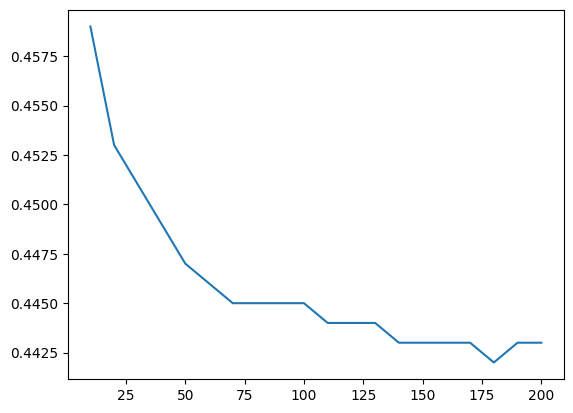

In [33]:
df_scores = pd.DataFrame(scores)
# df_scores
plt.plot(df_scores[0], df_scores[1])

In [34]:
# 200

## Question 4

Let's select the best max_depth:

- Try different values of max_depth: [10, 15, 20, 25]
- For each of these values,
    - try different values of n_estimators from 10 till 200 (with step 10)
    - calculate the mean RMSE
- Fix the random seed: random_state=1

What's the best max_depth, using the mean RMSE?

- 10
- 15
- 20
- 25

In [35]:
import numpy as np

In [36]:
scores = []
for i in [10, 15, 20, 25]:
    rmse_values = []
    for j in range(10, 201, 10):
        rf = RandomForestRegressor(max_depth=i, n_estimators=j, random_state=1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        rmse_values.append(root_mean_squared_error(y_val, y_pred))
    scores.append([i, np.mean(rmse_values)])
scores

[[10, 0.4417845630982896],
 [15, 0.4454432003790675],
 [20, 0.44614325108017344],
 [25, 0.4458847026386641]]

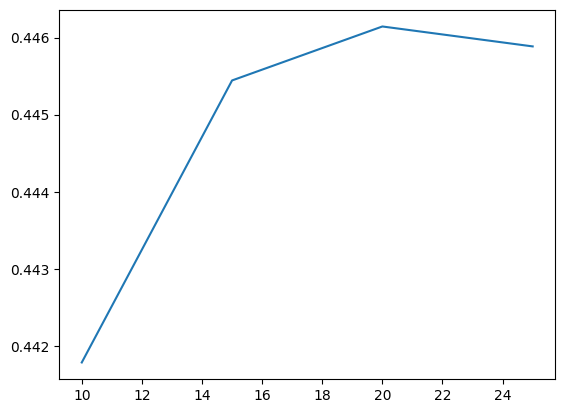

In [37]:
df_scores = pd.DataFrame(scores)
# df_scores
plt.plot(df_scores[0], df_scores[1])

In [38]:
# 10

## Question 5

We can extract feature importance information from tree-based models.

At each step of the decision tree learning algorithm, it finds the best split. When doing it, we can calculate "gain" - the reduction in impurity before and after the split. This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the `feature_importances_` field.

For this homework question, we'll find the most important feature:

- Train the model with these parameters:
    - n_estimators=10,
    - max_depth=20,
    - random_state=1,
    - n_jobs=-1 (optional)
- Get the feature importance information from this model

What's the most important feature (among these 4)?

- vehicle_weight
- horsepower
- acceleration
- engine_displacement

In [39]:
rf2 = RandomForestRegressor(max_depth=20, n_estimators=10, random_state=1, n_jobs=-1)
rf2.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
rf2.feature_importances_

array([1.14802317e-02, 6.24238520e-04, 3.40008101e-03, 6.00005191e-04,
       1.60596718e-02, 3.30698899e-03, 2.39282595e-03, 1.62263383e-03,
       1.13954586e-03, 9.59373777e-01])

In [41]:
df_train.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors'],
      dtype='object')

In [42]:
s = pd.Series(rf2.feature_importances_, index=df_train.columns)
s

engine_displacement    0.011480
num_cylinders          0.000624
horsepower             0.003400
vehicle_weight         0.000600
acceleration           0.016060
model_year             0.003307
origin                 0.002393
fuel_type              0.001623
drivetrain             0.001140
num_doors              0.959374
dtype: float64

In [43]:
s.sort_values(ascending=False)

num_doors              0.959374
acceleration           0.016060
engine_displacement    0.011480
horsepower             0.003400
model_year             0.003307
origin                 0.002393
fuel_type              0.001623
drivetrain             0.001140
num_cylinders          0.000624
vehicle_weight         0.000600
dtype: float64

In [44]:
# acceleration

## Question 6

Now let's train an XGBoost model! For this question, we'll tune the eta parameter:

- Install XGBoost
- Create DMatrix for train and validation
- Create a watchlist
- Train a model with these parameters for 100 rounds:


```
    xgb_params = {
        'eta': 0.3, 
        'max_depth': 6,
        'min_child_weight': 1,

        'objective': 'reg:squarederror',
        'nthread': 8,

        'seed': 1,
        'verbosity': 1,
    }
```

Now change eta from 0.3 to 0.1.

Which eta leads to the best RMSE score on the validation dataset?

- 0.3
- 0.1
- Both give equal value

In [45]:
# !pip install xgboost

In [46]:
import xgboost as xgb

In [47]:
features = dv.get_feature_names_out()
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [48]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}
xgb1 = xgb.train(xgb_params, dtrain, num_boost_round=100)

In [49]:
y_pred = xgb1.predict(dval)
root_mean_squared_error(y_val, y_pred)

0.443651264571433

In [50]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}
xgb2 = xgb.train(xgb_params, dtrain, num_boost_round=100)

In [51]:
y_pred = xgb2.predict(dval)
root_mean_squared_error(y_val, y_pred)

0.4193646182619471

In [52]:
# 0.1